
| <h1> **Seatwork 10.1** </h1> | <h1> **Improving RT-IoT2022 Analysis** </h1> |
|--- | --- |
Member 1: | Cabrera, Gabriel A.<br>
Member 2: | Catacutan, Anna Faith <br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | March 19, 2026
Date Submitted: | March 19, 2026


<hr>

## Extract
In this phase, we import all the needed python library to extract the needed data as well as visualize the dataset. After that, we load the dataset from the CSV file.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('RT_IOT2022.csv')
df.columns # Check the column names to see which one to check for correlation

Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max', 'flow_pkts_payload.tot',
  

## Transform

In this phase, we clean and preprocess the data: handle missing values, data types, and prepare for analysis.

In [4]:
# Data Cleaning and Preprocessing
print("Dataset Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum().sum())
print("Data Types:")
print(df.dtypes.value_counts())

Dataset Shape: (123117, 85)
Missing Values:
0
Data Types:
float64    56
int64      26
object      3
Name: count, dtype: int64


In [5]:
# Handle any infinite or NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)  # Drop rows with NaN if any
print("After cleaning shape:", df.shape)

After cleaning shape: (123117, 85)


## Load
In this phase, we perform exploratory data analysis to gain insights from the data.

,count,percent
Attack_type,,
DOS_SYN_Hping,94659,76.885
Thing_Speak,8108,6.586
ARP_poisioning,7750,6.295
MQTT_Publish,4146,3.368
NMAP_UDP_SCAN,2590,2.104
NMAP_XMAS_TREE_SCAN,2010,1.633
NMAP_OS_DETECTION,2000,1.624
NMAP_TCP_scan,1002,0.814
DDOS_Slowloris,534,0.434


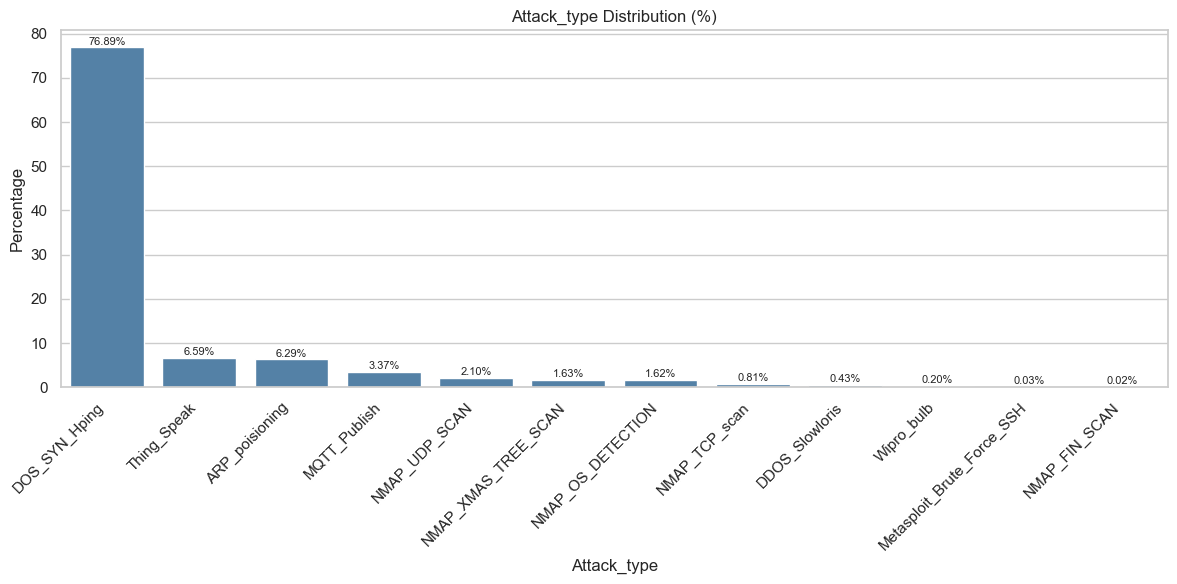

In [6]:
class_counts = df["Attack_type"].value_counts(dropna=False)
class_pct = (class_counts / len(df) * 100).round(3)
dist_df = pd.DataFrame({"count": class_counts, "percent": class_pct})
display(dist_df)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=class_pct.index.astype(str), y=class_pct.values, color="steelblue")
plt.title("Attack_type Distribution (%)")
plt.xlabel("Attack_type")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
for i, p in enumerate(class_pct.values):
    ax.text(i, p + (0.2 if p < 95 else -2), f"{p:.2f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

We can see that majority of attacks are executed using DOS_SYN_HPING. This means that the system is highly vulnerable to this type of attack, where the attacker floods the system with SYN packets to overwhelm it. We can also see that part of the attacks include detection or scan, around 5% of the total attacks, meaning that attackers frequently use network discovery to find vulnerabilities first before launching their actual attack.


Crosstab Attack_type vs proto:


proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,8,1927,5815
DDOS_Slowloris,0,529,5
DOS_SYN_Hping,0,94659,0
MQTT_Publish,0,4146,0
Metasploit_Brute_Force_SSH,0,29,8


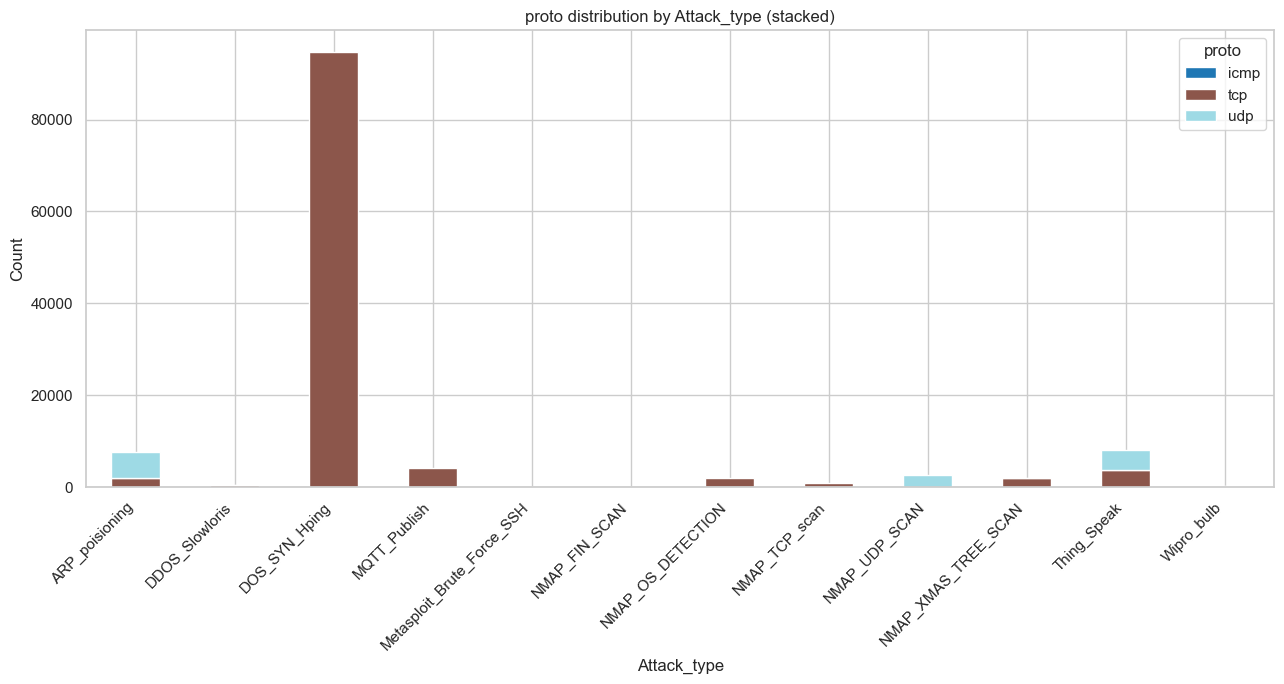

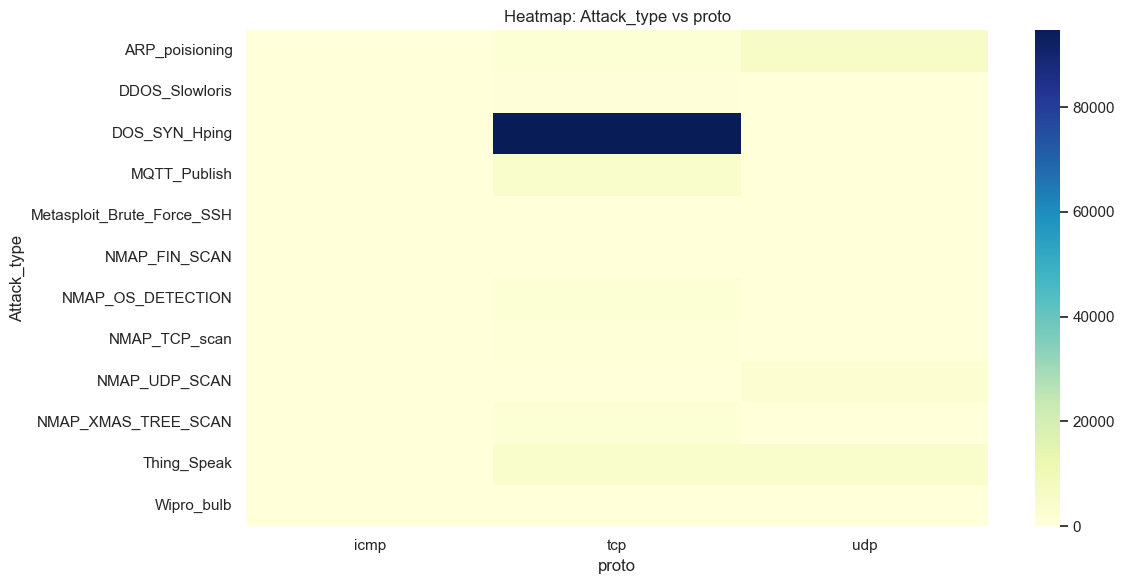


Crosstab Attack_type vs service:


service,-,dhcp,dns,http,irc,mqtt,ntp,radius,ssh,ssl
Attack_type,,,,,,,,,,
ARP_poisioning,546,26,5583,129,0,0,7,0,0,1459
DDOS_Slowloris,6,2,3,523,0,0,0,0,0,0
DOS_SYN_Hping,94659,0,0,0,0,0,0,0,0,0
MQTT_Publish,11,0,0,3,0,4132,0,0,0,0
Metasploit_Brute_Force_SSH,0,0,8,1,0,0,0,0,28,0


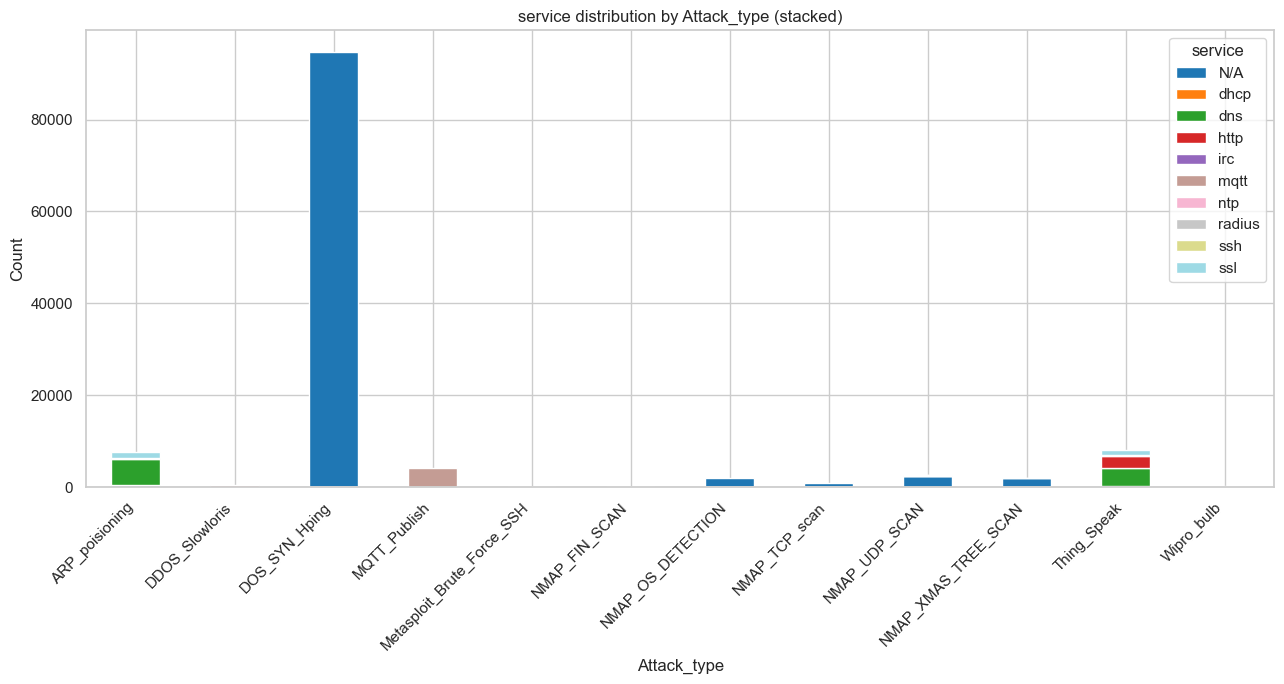

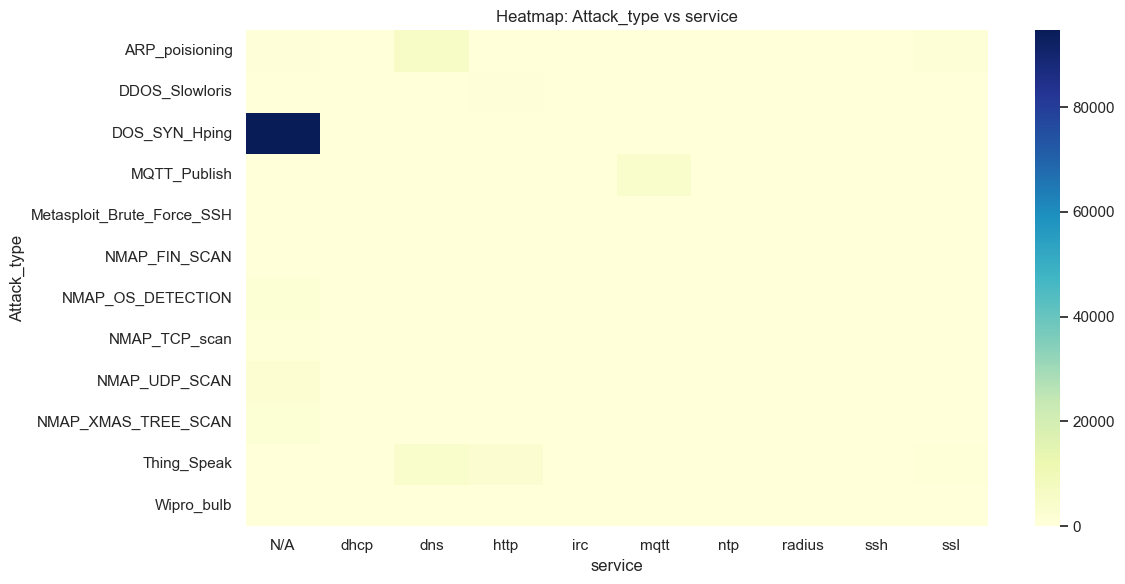

In [10]:
for feature in ["proto", "service"]:
    ctab = pd.crosstab(df["Attack_type"], df[feature])
    print(f"\nCrosstab Attack_type vs {feature}:")
    display(ctab.head())

    # Rename to make it more cohesive that there are missing values in the service column
    if feature == "service" and "-" in ctab.columns:
        ctab = ctab.rename(columns={"-": "N/A"})

    ctab.plot(kind="bar", stacked=True, figsize=(13, 7), colormap="tab20")
    plt.title(f"{feature} distribution by Attack_type (stacked)")
    plt.xlabel("Attack_type")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.heatmap(ctab, cmap="YlGnBu")
    plt.title(f"Heatmap: Attack_type vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Attack_type")
    plt.tight_layout()
    plt.show()



While TCP is the primary vector for these high-volume Denial of Service attacks and NMAP reconnaissance, the data highlights protocol-specific behaviors in smaller classes, such as NMAP_UDP_SCAN utilizing UDP for port discovery and ARP_poisoning exhibiting a hybrid TCP/UDP profile indicative of intercepted "Man-in-the-Middle" traffic. Legitimate IoT telemetry like Thing_Speak and MQTT_Publish make up less than 10% of the dataset, suggesting that any predictive model will be highly specialized in detecting aggressive network intrusions rather than monitoring standard operational patterns.

The service distribution chart highlights that a vast majority of network activity, particularly the dominant DOS_SYN_Hping and various NMAP scans, is classified as N/A, indicating these attacks target raw ports without established application-layer services. In contrast, the legitimate or protocol-specific traffic shows clear service mapping: MQTT_Publish is strictly associated with the mqtt service, while ARP_poisoning and Thing_Speak reveal a heavy reliance on dns and http, suggesting these categories involve standard web-based IoT communication and name-resolution interception.

,Attack_type,n,mean,std
0,ARP_poisioning,7750,15.893538,108.261070
1,DDOS_Slowloris,534,14.699148,14.124797
2,DOS_SYN_Hping,94659,0.000003,0.000002
3,MQTT_Publish,4146,43.397013,24.341563
4,Metasploit_Brute_Force_SSH,37,3.006557,5.210286
5,NMAP_FIN_SCAN,28,0.023614,0.108791
6,NMAP_OS_DETECTION,2000,0.000008,0.000007
7,NMAP_TCP_scan,1002,0.000019,0.000269
8,NMAP_UDP_SCAN,2590,0.737766,24.909755
9,NMAP_XMAS_TREE_SCAN,2010,0.001171,0.050426


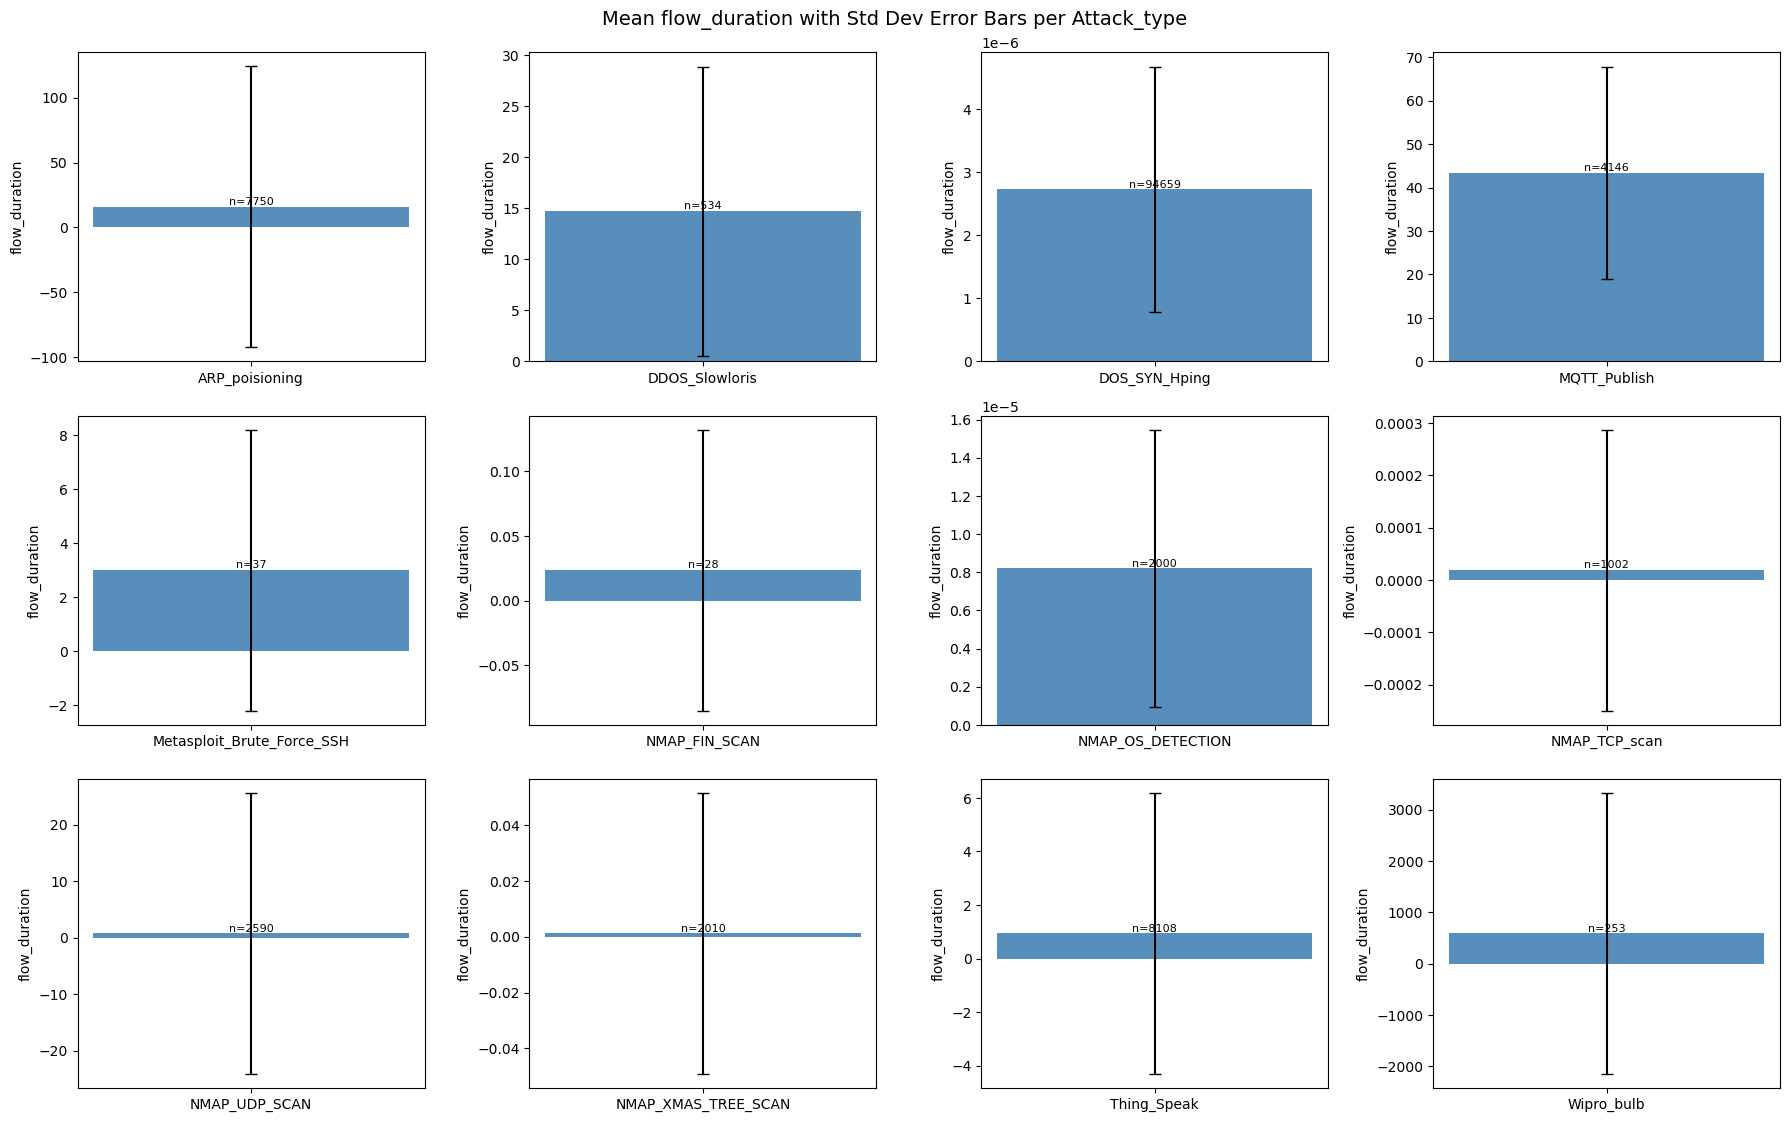

In [23]:
flow_stats = []
for cls, grp in df.groupby("Attack_type"):
    vals = pd.to_numeric(grp["flow_duration"], errors="coerce").dropna().to_numpy()
    if len(vals) == 0:
        continue
    flow_stats.append({
        "Attack_type": cls,
        "n": len(vals),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else float("nan")
    })

flow_stats_df = pd.DataFrame(flow_stats).sort_values("Attack_type")
display(flow_stats_df)

plot_df = flow_stats_df.reset_index(drop=True)
n_attacks = len(plot_df)
n_rows = 3 if n_attacks > 8 else 2
n_cols = int(np.ceil(n_attacks / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.8 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax = axes[i]
    attack = row["Attack_type"]
    mean_val = row["mean"]
    std_val = 0.0 if pd.isna(row["std"]) else row["std"]
    n_val = int(row["n"])

    ax.bar(
        [0],
        [mean_val],
        yerr=[std_val],
        width=0.35,
        color="steelblue",
        ecolor="black",
        capsize=4,
        alpha=0.9
    )
    ax.set_xticks([0])
    ax.set_xticklabels([str(attack)], rotation=0, ha="center")
    ax.set_ylabel("flow_duration")
    ax.text(0, mean_val, f"n={n_val}", ha="center", va="bottom", fontsize=8)


fig.suptitle("Mean flow_duration with Std Dev Error Bars per Attack_type", fontsize=14)
plt.tight_layout()
plt.show()


This highlight a massive disparity in how different traffic types behave in terms of time, ranging from microseconds to thousands of seconds. The dominant DOS_SYN_Hping attacks have a mean flow duration near 0.000003 seconds, indicating a "fire-and-forget" high-speed burst strategy, whereas Wipro_bulb and MQTT_Publish show significantly longer and more varied durations, characteristic of persistent IoT device connections. Furthermore, the very large error bars (standard deviation) across most categories, especially for Wipro_bulb—suggest that flow duration is highly inconsistent within each class, meaning while the means differ, the high variance makes duration alone a noisy predictor for classification.

,fwd_pkts_per_sec,bwd_pkts_per_sec,payload_bytes_per_second
fwd_pkts_per_sec,1.000000,0.999986,0.984281
bwd_pkts_per_sec,0.999986,1.000000,0.984291
payload_bytes_per_second,0.984281,0.984291,1.000000


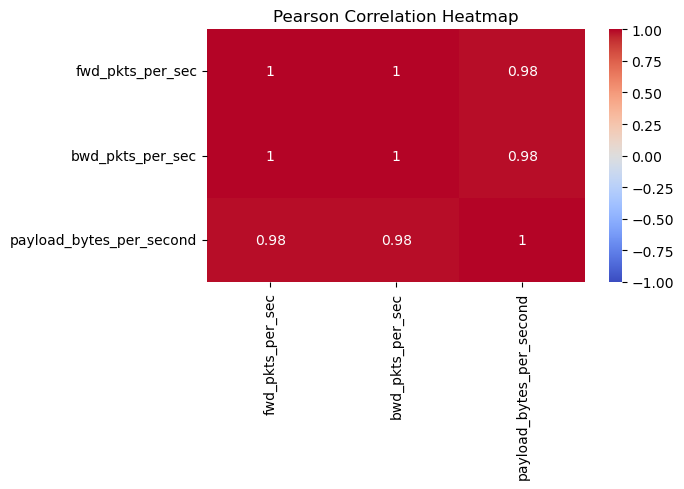

In [15]:
corr_cols = ["fwd_pkts_per_sec", "bwd_pkts_per_sec", "payload_bytes_per_second"]
available_corr = [c for c in corr_cols if c in df.columns]

corr_df = df[available_corr].apply(pd.to_numeric, errors="coerce")
corr_m = corr_df.corr(method="pearson")
display(corr_m)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_m, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

The table shows that all the packets coming in and out of the networks are mostly correlated, meaning that all of the packets are identical. This means these features are redundant—keeping all three provides very little unique information to a machine learning model.